In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
from langgraph.graph import START, END,StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [44]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [38]:
class MailState(BaseModel):
    query:str=""
    draft:str=""
    human_feedback:str=""
    final_response:str=""

In [45]:
### Defining the Nodes

def DraftMail(state:MailState) -> MailState:
    if state.human_feedback:
        draft=llm.invoke(f"""
                        You have generated this mail:{state.draft},
                        Human Feedback to apply :{state.human_feedback},
                        Rewite this draft email for {state.query} by applying the human feedback.
                         """)
    else:
        draft=llm.invoke(state.query)
    state.draft=str(draft.content)
    return state


def HumanFeedback(state:MailState) -> MailState:
    feedback = interrupt({
        "draft_mail": state.draft,
        "question":"Do you want to continue with this draft or do you want to change something?"
    })
    fb=(feedback or "").strip().lower()
    if fb in ("approved","yes","ok","continue"):
        state.human_feedback=""
        return state
    else:
        state.human_feedback=fb
        return state
    

def finalize_node(state:MailState) -> MailState:
    if state.human_feedback:
        state.final_response=state.human_feedback
        return state
    else:
        print("Email Sent Successfully!")
        state.final_response="Email Sent Successfully!"
        return state


def condition_routing(state:MailState) ->Literal["DraftMail","Finalize"]:
    if state.human_feedback:
        return "DraftMail"
    else:
        return "Finalize"


In [40]:
graph_builder=StateGraph(MailState)

# Nodes
graph_builder.add_node("DraftMail",DraftMail)
graph_builder.add_node("HumanFeedback",HumanFeedback)
graph_builder.add_node("Finalize",finalize_node)

# Edges
graph_builder.add_edge(START, "DraftMail")
graph_builder.add_edge("DraftMail","HumanFeedback")
graph_builder.add_conditional_edges("HumanFeedback",condition_routing)
graph_builder.add_edge("DraftMail",END)


graph=graph_builder.compile(checkpointer=InMemorySaver())

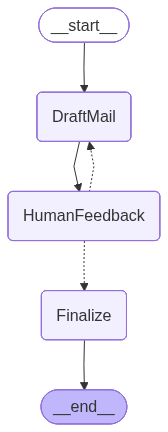

In [46]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [47]:
config={"configurable":{"thread_id":1}}

In [48]:
res=graph.invoke({"query":"Write an email to schedule a meeting tomorrow at 11am"},config=config)

In [49]:
print(res["draft"])

Here is an email to schedule a meeting:

Subject: Meeting Invitation for Tomorrow

Dear [Recipient's Name],

I hope this email finds you well. I would like to schedule a meeting with you for tomorrow at 11:00am. Would you be available to meet at this time?

If this time works for you, please let me know and I will make sure to reserve a meeting space. If you have any conflicts, please let me know as soon as possible so we can schedule an alternative time.

I look forward to hearing back from you and meeting with you tomorrow.

Best regards,
[Your Name]


In [53]:
res= graph.invoke(Command(resume="Recipient Name is John Doe My name is Sahbaz Khan"),config=config)

In [60]:
print(res["draft"])
# res

Here is the rewritten email:

Subject: Meeting Invitation for Tomorrow - Discussion on Current Projects

Dear John Doe,

I hope this email finds you well. I am writing to invite you to a meeting scheduled for tomorrow at 11:00am to discuss the current projects we are working on. The purpose of the meeting is to review our progress, address any challenges we are facing, and outline the next steps to ensure the successful completion of these projects.

During the meeting, I would like to touch base on the following topics:
- Review of project timelines and deadlines
- Discussion of any obstacles or concerns that need to be addressed
- Allocation of tasks and responsibilities
- Overview of the project's budget and resource utilization

The meeting will be approximately 60 minutes long, and I will make sure to reserve a meeting space that can accommodate all attendees. If this time works for you, please let me know by return email as soon as possible. If you have any conflicts or are unabl

In [61]:
res= graph.invoke(Command(resume="yes"),config=config)

In [62]:
res

{'query': 'Write an email to schedule a meeting tomorrow at 11am',
 'draft': "Here is the rewritten email:\n\nSubject: Meeting Invitation for Tomorrow - Discussion on Current Projects\n\nDear John Doe,\n\nI hope this email finds you well. I am writing to invite you to a meeting scheduled for tomorrow at 11:00am to discuss the current projects we are working on. The purpose of the meeting is to review our progress, address any challenges we are facing, and outline the next steps to ensure the successful completion of these projects.\n\nDuring the meeting, I would like to touch base on the following topics:\n- Review of project timelines and deadlines\n- Discussion of any obstacles or concerns that need to be addressed\n- Allocation of tasks and responsibilities\n- Overview of the project's budget and resource utilization\n\nThe meeting will be approximately 60 minutes long, and I will make sure to reserve a meeting space that can accommodate all attendees. If this time works for you, pl